# 03 · Model Training & Comparison

Trains and compares three classification models:
- **XGBoost** — Gradient boosting (with Optuna hyperparameter optimization)
- **Random Forest** — Ensemble of decision trees (with Optuna hyperparameter optimization)
- **Logistic Regression** — Linear baseline

**Data split:** 75% train, 15% validation, 10% test.
- **Training set**: trains the models
- **Validation set**: all evaluation, comparison, and model selection happens here
- **Test set**: held completely separate for final evaluation (used in notebook 04)

All model training is visible in this notebook.

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import optuna
from optuna.samplers import TPESampler

from src.features.engineering import FEATURE_COLUMNS, LABEL_MAP, INV_LABEL_MAP

PROCESSED_PATH = pathlib.Path("../data/processed/matches_features.csv")
MODEL_PATH = pathlib.Path("../models")

## Load & prepare data

In [ ]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=["Date"])
print(f"Dataset: {len(df):,} matches")
print(f"Outcomes:\n{df['FTR'].value_counts().to_dict()}\n")

X = df[FEATURE_COLUMNS].astype("float32")
y = df["FTR"].map(LABEL_MAP)

# First split: 90% for training+validation, 10% for test (held out)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Second split: of the remaining 90%, split into 75% train, 15% validation
# (0.1667 ≈ 15/90, leaving 0.8333 ≈ 75/90 for training)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1667, random_state=42, stratify=y_trainval
)

print(f"Train:      {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%) ← used for training")
print(f"Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%) ← used for evaluation & selection")
print(f"Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%) ← held out (not used here)")

Dataset: 15,072 matches
Outcomes:
{'H': 6959, 'A': 4409, 'D': 3704}

Train:      11,302 (75.0%) ← used for training
Validation: 2,262 (15.0%) ← used for evaluation & selection
Test:       1,508 (10.0%) ← held out (not used here)


## Class weights (imbalance compensation)

In [ ]:
CLASS_WEIGHTS = {0: 1.0, 1: 1.1, 2: 1.1}  # Slightly upweight draws and away wins to address class imbalance
sample_weights_train = y_train.map(CLASS_WEIGHTS).values
print(f"Class weights: {CLASS_WEIGHTS}")

Class weights: {0: 1.0, 1: 1.1, 2: 1.1}


---\n## Model 1: XGBoost with Optuna Hyperparameter Tuning

### Optuna Study for XGBoost

In [ ]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
    }
    
    model = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        verbosity=0,
        **params
    )
    
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Run Optuna study
optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler_xgb = TPESampler(seed=42)
study_xgb = optuna.create_study(direction="maximize", sampler=sampler_xgb)
study_xgb.optimize(objective_xgb, n_trials=10, show_progress_bar=True)

print(f"\n XGBoost Optuna Results:")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best accuracy: {study_xgb.best_value:.4f}")
print(f"Best params:\n{study_xgb.best_params}")

Best trial: 2. Best value: 0.54023: 100%|██████████| 10/10 [00:15<00:00,  1.52s/it]


 XGBoost Optuna Results:
Best trial: 2
Best accuracy: 0.5402
Best params:
{'n_estimators': 450, 'max_depth': 3, 'learning_rate': 0.01855998084649058, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'min_child_weight': 3}


### Train XGBoost with Best Hyperparameters

In [ ]:
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    verbosity=0,
    **study_xgb.best_params
)

xgb.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

y_pred_xgb = xgb.predict(X_val)
y_proba_xgb = xgb.predict_proba(X_val)
acc_xgb = accuracy_score(y_val, y_pred_xgb)
print(f"XGBoost Validation Accuracy: {acc_xgb:.4f}")

XGBoost Validation Accuracy: 0.5402


## Model 2: Random Forest with Optuna Hyperparameter Tuning

### Optuna Study for Random Forest

In [ ]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=25),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }
    
    model = RandomForestClassifier(
        class_weight=CLASS_WEIGHTS,
        random_state=42,
        n_jobs=-1,
        **params
    )
    
    model.fit(X_train, y_train, sample_weight=sample_weights_train)
    
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

# Run Optuna study
sampler_rf = TPESampler(seed=42)
study_rf = optuna.create_study(direction="maximize", sampler=sampler_rf)
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

print(f"\n📊 Random Forest Optuna Results:")
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best accuracy: {study_rf.best_value:.4f}")
print(f"Best params:\n{study_rf.best_params}")

Best trial: 3. Best value: 0.541114: 100%|██████████| 20/20 [00:10<00:00,  1.93it/s]


📊 Random Forest Optuna Results:
Best trial: 3
Best accuracy: 0.5411
Best params:
{'n_estimators': 150, 'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2'}


### Train Random Forest with Best Hyperparameters

In [ ]:
rf = RandomForestClassifier(
    class_weight=CLASS_WEIGHTS,
    random_state=42,
    n_jobs=-1,
    **study_rf.best_params
)

rf.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f"Random Forest Validation Accuracy: {acc_rf:.4f}")

Random Forest Validation Accuracy: 0.5411


## Model 3: Logistic Regression

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr = LogisticRegression(
    max_iter=1000,
    class_weight=CLASS_WEIGHTS,
    random_state=42,
    n_jobs=-1,
)

lr.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

y_pred_lr = lr.predict(X_val_scaled)
y_proba_lr = lr.predict_proba(X_val_scaled)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f"Logistic Regression Validation Accuracy: {acc_lr:.4f}")

Logistic Regression Validation Accuracy: 0.5265


## Model Comparison (Validation Set)

In [ ]:
comparison = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "Logistic Regression"],
    "Validation Accuracy": [acc_xgb, acc_rf, acc_lr],
})
comparison = comparison.sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))
print(f"\n🏆 Best model (validation): {comparison.iloc[0]['Model']} ({comparison.iloc[0]['Validation Accuracy']:.4f})")

              Model  Validation Accuracy
      Random Forest             0.541114
            XGBoost             0.540230
Logistic Regression             0.526525

🏆 Best model (validation): Random Forest (0.5411)


## Evaluation Metrics (Validation Set Only)

### Confusion Matrices

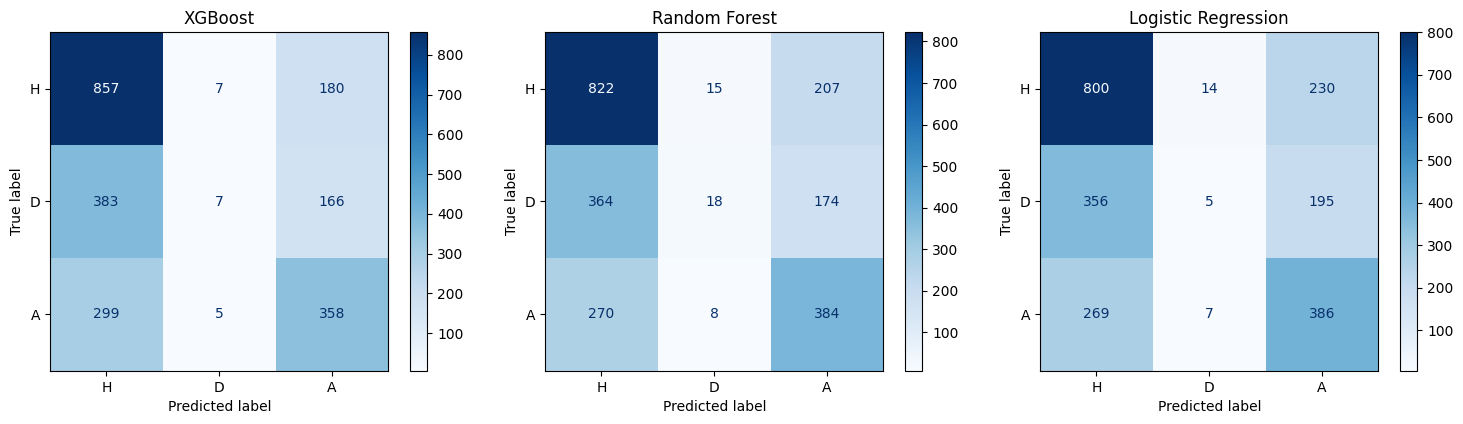

In [ ]:
target_names = [INV_LABEL_MAP[i] for i in sorted(INV_LABEL_MAP)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, model_name in zip(
    axes,
    [y_pred_xgb, y_pred_rf, y_pred_lr],
    ["XGBoost", "Random Forest", "Logistic Regression"],
):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

### Classification Reports

In [ ]:
print("=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(y_val, y_pred_xgb, target_names=target_names))

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_val, y_pred_rf, target_names=target_names))

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_val, y_pred_lr, target_names=target_names))

XGBOOST
              precision    recall  f1-score   support

           H       0.56      0.82      0.66      1044
           D       0.37      0.01      0.02       556
           A       0.51      0.54      0.52       662

    accuracy                           0.54      2262
   macro avg       0.48      0.46      0.40      2262
weighted avg       0.50      0.54      0.47      2262


RANDOM FOREST
              precision    recall  f1-score   support

           H       0.56      0.79      0.66      1044
           D       0.44      0.03      0.06       556
           A       0.50      0.58      0.54       662

    accuracy                           0.54      2262
   macro avg       0.50      0.47      0.42      2262
weighted avg       0.52      0.54      0.48      2262


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           H       0.56      0.77      0.65      1044
           D       0.19      0.01      0.02       556
           A       0.48      0.

### ROC Curves (One-vs-Rest)

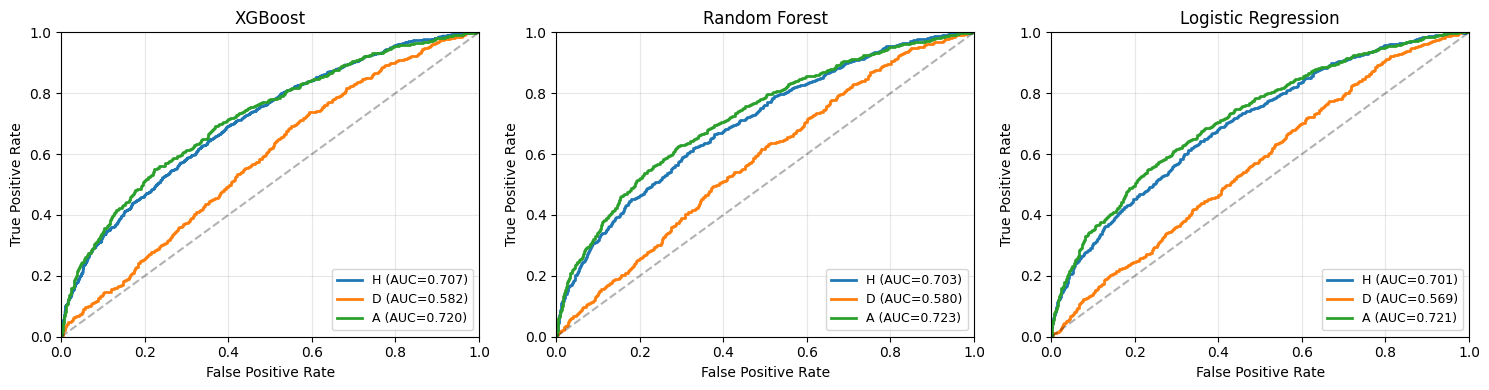

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (y_proba, model_name) in zip(
    axes,
    [(y_proba_xgb, "XGBoost"), (y_proba_rf, "Random Forest"), (y_proba_lr, "Logistic Regression")],
):
    for i in sorted(INV_LABEL_MAP):
        y_true_binary = (y_val == i).astype(int)
        fpr, tpr, _ = roc_curve(y_true_binary, y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{INV_LABEL_MAP[i]} (AUC={roc_auc:.3f})", linewidth=2)
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name}")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Calibration Plots

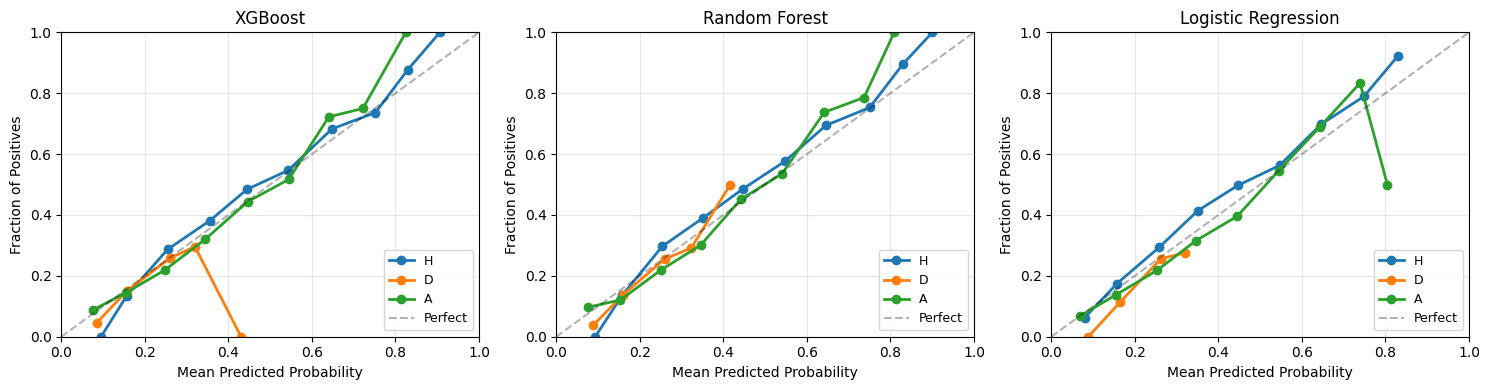

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (y_proba, model_name) in zip(
    axes,
    [(y_proba_xgb, "XGBoost"), (y_proba_rf, "Random Forest"), (y_proba_lr, "Logistic Regression")],
):
    for i in sorted(INV_LABEL_MAP):
        y_true_binary = (y_val == i).astype(int)
        prob_true, prob_pred = calibration_curve(
            y_true_binary, y_proba[:, i], n_bins=10, strategy="uniform"
        )
        ax.plot(prob_pred, prob_true, "o-", label=INV_LABEL_MAP[i], linewidth=2, markersize=6)
    
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{model_name}")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Save Best Model

In [ ]:
# Save the best models (highest validation accuracy)
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save XGBoost
xgb_file = MODEL_PATH / "xgb_match_predict_model.json"
xgb.save_model(str(xgb_file))
print(f"✓ Saved XGBoost → {xgb_file}")
print(f"  Validation accuracy: {acc_xgb:.4f}")

# Save Random Forest
import joblib
rf_file = MODEL_PATH / "rf_match_predict_model.pkl"
joblib.dump(rf, str(rf_file))
print(f"✓ Saved Random Forest → {rf_file}")
print(f"  Validation accuracy: {acc_rf:.4f}")

print(f"\n⚠️  Test set ({len(X_test):,} matches) remains held out for final evaluation.")

✓ Saved XGBoost → ../models/xgb_match_predict_model.json
  Validation accuracy: 0.5402
✓ Saved Random Forest → ../models/rf_match_predict_model.pkl
  Validation accuracy: 0.5411

⚠️  Test set (1,508 matches) remains held out for final evaluation.


> Proceed to **04_model_evaluation.ipynb** to evaluate on the test set.